# Dataset integrity verification

Checks the 28×28 `gen9randombattle` gauntlet (784 CSVs). This notebook does **not**
interpret skill; it only asks whether the files are complete, parseable, and internally
consistent.

**Taxonomy**

| IDs | Paradigm | Games / matchup |
|---|---|---|
| v1–v14 | Heuristic ladder | 10,000 (1,000 if the opponent is v18/v19/v20) |
| v15–v17 | 1-ply minimax | same |
| v18–v20 | IS-MCTS | **1,000** whenever either side is v18/v19/v20 |
| v21 / v22 | IL hybrid / IL pure | 10,000 (1,000 vs MCTS) |
| six baselines | `random`, `max_power`, `one_step`, `safe_one_step`, `abyssal`, `simple_heuristic` | same as heuristics |

Do not label v17 as MCTS or v19–v20 as imitation.

## 1 · Setup


In [1]:
import os, csv, re, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

PROJECT_ROOT = Path("/home/sirp/Documents/MUDS/TFM_Pokemon").resolve()
BENCHMARK_DIR = PROJECT_ROOT / "data/benchmarks/all_10k/gen9randombattle"
PLOTS_DIR = PROJECT_ROOT / "src/p00_core/reporting/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Taxonomy: v1–v14 heuristic, v15–v17 1-ply minimax, v18–v20 IS-MCTS (n=1k),
# v21 IL hybrid, v22 IL pure, then six baselines.
ALL_AGENTS = [
    "v1","v2","v3","v4","v5","v6","v7","v8","v9","v10","v11","v12","v13","v14",  # heuristic
    "v15","v16","v17",  # 1-ply minimax
    "v18","v19","v20",  # IS-MCTS (REDUCED)
    "v21","v22",        # IL hybrid / pure
    "random","max_power","abyssal","one_step","safe_one_step","simple_heuristic",
]

# Agents that ran with 1k games instead of 10k
REDUCED_AGENTS = {"v18", "v19", "v20"}
EXPECTED_ROWS_FULL = 10_000
EXPECTED_ROWS_REDUCED = 1_000

# Known non-matchup files in the directory
KNOWN_NON_MATCHUP_FILES = {"elo_summary.csv", "monitor.log", "matchup_performance.csv", ".gitkeep"}

# ── Schema definitions ──
# Base 50-column schema (v1-v12 + baselines vs v1-v14 + baselines)
BASE_COLUMNS = [
    "battle_id","format","heuristic","opponent","winner","won","turns",
    "decisions_us","decisions_opp","fallback_moves_us","fallback_moves_opp",
    "error_moves_us","error_moves_opp","fainted_us","remaining_pokemon_us",
    "total_hp_us","fainted_opp","remaining_pokemon_opp","total_hp_opp",
    "team_us","team_opp","side_conditions_us","side_conditions_opp",
    "voluntary_switches_us","forced_switches_us","voluntary_switches_opp",
    "forced_switches_opp","move_stats_us","move_stats_opp",
    "crit_us","crit_opp","miss_us","miss_opp",
    "supereffective_us","supereffective_opp","hp_perc_us","hp_perc_opp",
    "hazard_sets_us","hazard_sets_opp","hazard_removals_us","hazard_removals_opp",
    "setup_uses_us","setup_uses_opp","ko_checks_us","ko_checks_opp",
    "matchup_switches_us","matchup_switches_opp",
    "terastallized_us","terastallized_opp","timestamp"
]

# Extended 70-column schema — adds 20 columns between terastallized_opp and timestamp
EXTENDED_EXTRA_COLUMNS = [
    "ko_guards_us","ko_guards_opp","loop_guards_us","loop_guards_opp",
    "xgb_switches_us","xgb_switches_opp","xgb_stays_us","xgb_stays_opp",
    "xgb_prob_sum_us","xgb_prob_sum_opp",
    "search_switches_us","search_switches_opp","search_moves_us","search_moves_opp",
    "endgame_solves_us","endgame_solves_opp","search_diff_us","search_diff_opp",
    "total_turns_us","total_turns_opp"
]
EXTENDED_COLUMNS = BASE_COLUMNS[:-1] + EXTENDED_EXTRA_COLUMNS + ["timestamp"]  # 70 cols

# Columns shared by both schemas (for downstream analysis)
COMMON_COLUMNS = BASE_COLUMNS  # all 50 base columns exist in both schemas

# Battle ID pattern: legacy or worker-prefixed
BATTLE_ID_PATTERN = re.compile(r"^(p\d+_[0-9a-f]+_)?battle-gen9randombattle-\d+$")

print(f"Project Root       : {PROJECT_ROOT}")
print(f"Benchmark Dir      : {BENCHMARK_DIR}")
print(f"Agents             : {len(ALL_AGENTS)}")
print(f"Expected Matchups  : {len(ALL_AGENTS)**2}")
print(f"Reduced (1k) Agents: {REDUCED_AGENTS}")
print(f"Base Schema Cols   : {len(BASE_COLUMNS)}")
print(f"Extended Schema Cols: {len(EXTENDED_COLUMNS)}")
print("Taxonomy           : v1–v14 heuristic | v15–v17 minimax | v18–v20 MCTS | v21–v22 IL")


Project Root       : /home/sirp/Documents/MUDS/TFM_Pokemon
Benchmark Dir      : /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Agents             : 28
Expected Matchups  : 784
Reduced (1k) Agents: {'v20', 'v19', 'v18'}
Base Schema Cols   : 50
Extended Schema Cols: 70


## 2 · File Inventory & Size Distribution

Expected Matchup Files : 784
Found on Disk          : 784 / 784
Missing Files          : 0
Known Non-Matchup Files: {'elo_summary.csv', 'monitor.log', 'matchup_performance.csv', '.gitkeep'}
Unexpected Files       : 0 
Total Matchup Disk Size: 5.80 GB
Min File Size          : 0.86 MB
Max File Size          : 10.63 MB
Mean File Size         : 7.58 MB
Median File Size       : 9.05 MB

✅ All 784 expected matchup files present.


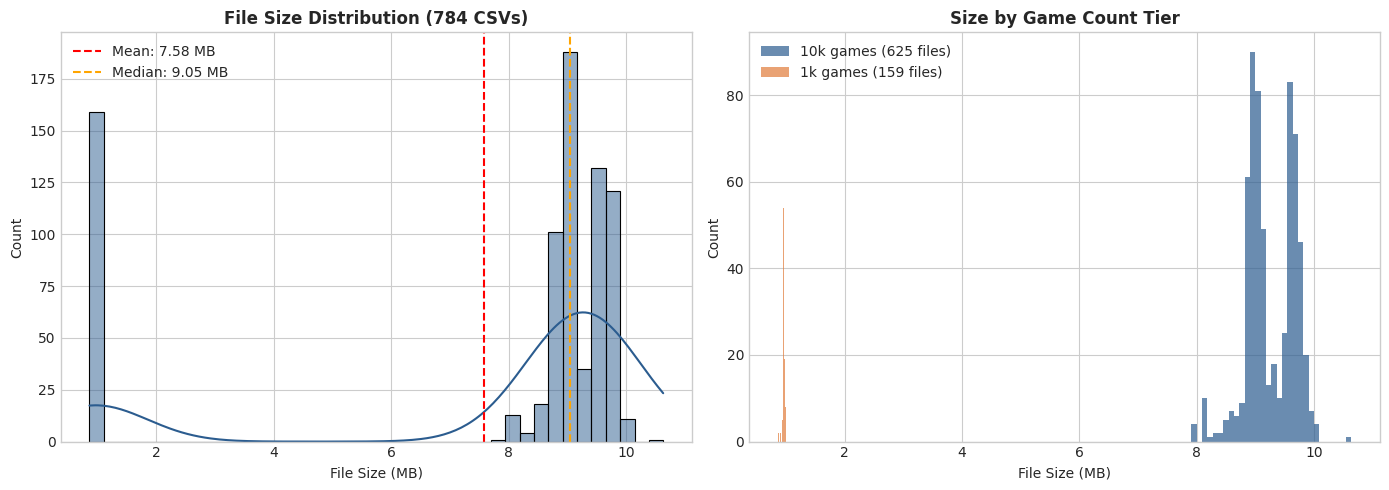

In [2]:
expected_paths = {f"{ag}_vs_{opp}.csv": BENCHMARK_DIR / f"{ag}_vs_{opp}.csv"
                  for ag in ALL_AGENTS for opp in ALL_AGENTS}

missing_files = [name for name, path in expected_paths.items() if not path.exists()]
existing_files = {name: path for name, path in expected_paths.items() if path.exists()}

# Check for unexpected files (excluding known non-matchup files)
all_disk_files = set(f.name for f in BENCHMARK_DIR.iterdir() if f.is_file())
unexpected_files = all_disk_files - set(expected_paths.keys()) - KNOWN_NON_MATCHUP_FILES

file_sizes_mb = {name: path.stat().st_size / (1024**2) for name, path in existing_files.items()}
total_gb = sum(file_sizes_mb.values()) / 1024

print(f"Expected Matchup Files : {len(expected_paths)}")
print(f"Found on Disk          : {len(existing_files)} / {len(expected_paths)}")
print(f"Missing Files          : {len(missing_files)}")
print(f"Known Non-Matchup Files: {KNOWN_NON_MATCHUP_FILES}")
print(f"Unexpected Files       : {len(unexpected_files)} {list(unexpected_files)[:5] if unexpected_files else ''}")
print(f"Total Matchup Disk Size: {total_gb:.2f} GB")
print(f"Min File Size          : {min(file_sizes_mb.values()):.2f} MB")
print(f"Max File Size          : {max(file_sizes_mb.values()):.2f} MB")
print(f"Mean File Size         : {np.mean(list(file_sizes_mb.values())):.2f} MB")
print(f"Median File Size       : {np.median(list(file_sizes_mb.values())):.2f} MB")

if missing_files:
    print(f"\n❌ MISSING FILES: {missing_files}")
else:
    print("\n✅ All 784 expected matchup files present.")

# Size distribution: split by 10k vs 1k game tiers
def involves_reduced(name):
    parts = name.replace(".csv", "").split("_vs_")
    return any(a in REDUCED_AGENTS for a in parts)

sizes_10k = [s for name, s in file_sizes_mb.items() if not involves_reduced(name)]
sizes_1k = [s for name, s in file_sizes_mb.items() if involves_reduced(name)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

all_sizes = list(file_sizes_mb.values())
sns.histplot(all_sizes, bins=40, kde=True, color="#2b5c8f", ax=ax1)
ax1.axvline(np.mean(all_sizes), color="red", ls="--", label=f"Mean: {np.mean(all_sizes):.2f} MB")
ax1.axvline(np.median(all_sizes), color="orange", ls="--", label=f"Median: {np.median(all_sizes):.2f} MB")
ax1.set_title("File Size Distribution (784 CSVs)", fontweight="bold")
ax1.set_xlabel("File Size (MB)")
ax1.set_ylabel("Count")
ax1.legend()

ax2.hist(sizes_10k, bins=30, alpha=0.7, label=f"10k games ({len(sizes_10k)} files)", color="#2b5c8f")
ax2.hist(sizes_1k, bins=15, alpha=0.7, label=f"1k games ({len(sizes_1k)} files)", color="#e07b39")
ax2.set_title("Size by Game Count Tier", fontweight="bold")
ax2.set_xlabel("File Size (MB)")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "file_size_distribution.png", dpi=300)
plt.show()

## 3 · Row Count Validation
Every matchup involving `v18`, `v19`, or `v20` should have **1 000 rows**. All others: **10 000 rows**.

In [3]:
row_count_errors = []
row_counts = {}

for name, path in sorted(existing_files.items()):
    expected_rows = EXPECTED_ROWS_REDUCED if involves_reduced(name) else EXPECTED_ROWS_FULL

    with open(path, "r", encoding="utf-8") as f:
        actual_lines = sum(1 for _ in f) - 1  # subtract header

    row_counts[name] = actual_lines
    if actual_lines != expected_rows:
        row_count_errors.append((name, expected_rows, actual_lines))

total_rows = sum(row_counts.values())
files_10k = sum(1 for v in row_counts.values() if v == EXPECTED_ROWS_FULL)
files_1k = sum(1 for v in row_counts.values() if v == EXPECTED_ROWS_REDUCED)

expected_total = (files_10k * EXPECTED_ROWS_FULL) + (files_1k * EXPECTED_ROWS_REDUCED)

print(f"Total Rows Across Dataset : {total_rows:,}")
print(f"Files with 10,000 rows    : {files_10k}")
print(f"Files with 1,000 rows     : {files_1k}")
print(f"Row Count Errors          : {len(row_count_errors)}")
print(f"Expected Total            : {expected_total:,}")
print(f"Match                     : {'✅' if total_rows == expected_total else '❌'} "
      f"({total_rows:,} vs {expected_total:,})")

if row_count_errors:
    print("\n❌ ROW COUNT MISMATCHES:")
    for name, expected, actual in row_count_errors[:20]:
        print(f"  {name}: expected {expected:,}, got {actual:,}")
else:
    print("\n✅ All row counts match expectations.")

Total Rows Across Dataset : 6,409,000
Files with 10,000 rows    : 625
Files with 1,000 rows     : 159
Row Count Errors          : 0
Expected Total            : 6,409,000
Match                     : ✅ (6,409,000 vs 6,409,000)

✅ All row counts match expectations.


## 4 · Schema Uniformity & CSV Parse Health
Two valid schemas exist:
- **Base (50 cols):** matchups where the recording batch used the original format (347 files)
- **Extended (70 cols):** adds 20 telemetry columns (ko_guards, loop_guards, xgb_*, search_*, endgame_solves, total_turns) — 437 files

Both are valid. All 50 base columns are present in both schemas.

In [4]:
schema_errors = []
parse_errors = []
schema_counts = Counter()  # {ncols: count}
file_schemas = {}  # {filename: ncols}

for name, path in sorted(existing_files.items()):
    try:
        df = pd.read_csv(path, nrows=0)
        cols = list(df.columns)
        ncols = len(cols)
        schema_counts[ncols] += 1
        file_schemas[name] = ncols

        if ncols == 50 and cols != BASE_COLUMNS:
            schema_errors.append((name, ncols, "column names don't match BASE_COLUMNS"))
        elif ncols == 70 and cols != EXTENDED_COLUMNS:
            schema_errors.append((name, ncols, "column names don't match EXTENDED_COLUMNS"))
        elif ncols not in (50, 70):
            schema_errors.append((name, ncols, f"unexpected column count: {ncols}"))
    except Exception as e:
        parse_errors.append((name, str(e)))

# Full parse test on a stratified sample: 15 base + 15 extended + 10 from 1k tier
base_files = [n for n, nc in file_schemas.items() if nc == 50][:15]
ext_files = [n for n, nc in file_schemas.items() if nc == 70][:15]
reduced_files = [n for n in existing_files if involves_reduced(n)][:10]
full_parse_sample = list(set(base_files + ext_files + reduced_files))

for name in full_parse_sample:
    try:
        df = pd.read_csv(existing_files[name])
        expected_ncols = file_schemas.get(name, 50)
        if len(df.columns) != expected_ncols:
            parse_errors.append((name, f"got {len(df.columns)} cols, expected {expected_ncols}"))
        if len(df) != row_counts[name]:
            parse_errors.append((name, f"pandas read {len(df)} rows, expected {row_counts[name]}"))
    except Exception as e:
        parse_errors.append((name, str(e)))

print(f"Schema Distribution:")
for ncols, count in sorted(schema_counts.items()):
    label = "base" if ncols == 50 else "extended" if ncols == 70 else "UNKNOWN"
    print(f"  {ncols}-column ({label}): {count} files")

print(f"\nSchema Errors      : {len(schema_errors)}")
print(f"Parse Errors       : {len(parse_errors)}")
print(f"Full Parse Sample  : {len(full_parse_sample)} files tested")

# Verify base columns are a subset of extended
base_set = set(BASE_COLUMNS)
ext_set = set(EXTENDED_COLUMNS)
print(f"\nBase ⊆ Extended    : {'✅' if base_set.issubset(ext_set) else '❌'}")
print(f"Extra Cols in Ext  : {len(ext_set - base_set)} → {sorted(ext_set - base_set)[:5]}...")

if schema_errors:
    print("\n❌ SCHEMA MISMATCHES:")
    for name, nc, msg in schema_errors[:5]:
        print(f"  {name} ({nc} cols): {msg}")
elif parse_errors:
    print("\n❌ PARSE ERRORS:")
    for name, err in parse_errors[:5]:
        print(f"  {name}: {err}")
else:
    print("\n✅ All 784 files match one of the two valid schemas (50 or 70 cols). Parse tests passed.")

Schema Distribution:
  50-column (base): 347 files
  70-column (extended): 437 files

Schema Errors      : 0
Parse Errors       : 0
Full Parse Sample  : 40 files tested

Base ⊆ Extended    : ✅
Extra Cols in Ext  : 20 → ['endgame_solves_opp', 'endgame_solves_us', 'ko_guards_opp', 'ko_guards_us', 'loop_guards_opp']...

✅ All 784 files match one of the two valid schemas (50 or 70 cols). Parse tests passed.


## 5 · Filename ↔ Content Consistency
For each file `X_vs_Y.csv`, verify `heuristic == X` and `opponent == Y` across every row.

In [5]:
consistency_errors = []

for name, path in sorted(existing_files.items()):
    parts = name.replace(".csv", "").split("_vs_")
    expected_heuristic, expected_opponent = parts[0], parts[1]

    df = pd.read_csv(path, usecols=["heuristic", "opponent"])

    bad_h = (df["heuristic"] != expected_heuristic).sum()
    bad_o = (df["opponent"] != expected_opponent).sum()

    if bad_h > 0 or bad_o > 0:
        consistency_errors.append({
            "file": name,
            "bad_heuristic_rows": int(bad_h),
            "bad_opponent_rows": int(bad_o),
            "heuristic_values": df["heuristic"].unique().tolist(),
            "opponent_values": df["opponent"].unique().tolist(),
        })

print(f"Files Checked      : {len(existing_files)}")
print(f"Consistency Errors : {len(consistency_errors)}")

if consistency_errors:
    print("\n❌ FILENAME ↔ CONTENT MISMATCHES:")
    for err in consistency_errors[:10]:
        print(f"  {err['file']}: heuristic={err['heuristic_values']}, opponent={err['opponent_values']}")
else:
    print("\n✅ All files: heuristic/opponent columns match filename.")

Files Checked      : 784
Consistency Errors : 0

✅ All files: heuristic/opponent columns match filename.


## 6 · Domain Validation
- `won ∈ {0, 1}`
- `format == "gen9randombattle"`
- `winner ∈ {heuristic_value, opponent_value}`
- `won == 1 ⟺ winner == heuristic`

In [6]:
domain_errors = []

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["format", "heuristic", "opponent", "winner", "won"])

    errors = {}

    # won ∈ {0, 1}
    bad_won = set(df["won"].unique()) - {0, 1}
    if bad_won:
        errors["won_domain"] = bad_won

    # format check
    bad_fmt = set(df["format"].unique()) - {"gen9randombattle"}
    if bad_fmt:
        errors["format_domain"] = bad_fmt

    # winner must be either heuristic or opponent value
    h_val = df["heuristic"].iloc[0]
    o_val = df["opponent"].iloc[0]
    bad_winner = set(df["winner"].unique()) - {h_val, o_val}
    if bad_winner:
        errors["winner_domain"] = bad_winner

    # won/winner consistency: won==1 ↔ winner==heuristic
    won_mismatch = ((df["won"] == 1) & (df["winner"] != h_val)).sum()
    lost_mismatch = ((df["won"] == 0) & (df["winner"] != o_val)).sum()
    if won_mismatch > 0:
        errors["won_winner_inconsistent"] = int(won_mismatch)
    if lost_mismatch > 0:
        errors["lost_winner_inconsistent"] = int(lost_mismatch)

    if errors:
        domain_errors.append({"file": name, **errors})

print(f"Files Checked   : {len(existing_files)}")
print(f"Domain Errors   : {len(domain_errors)}")

if domain_errors:
    print("\n❌ DOMAIN VIOLATIONS:")
    for err in domain_errors[:10]:
        print(f"  {err}")
else:
    print("\n✅ All domain checks passed (won, format, winner consistency).")

Files Checked   : 784
Domain Errors   : 0

✅ All domain checks passed (won, format, winner consistency).


## 7 · Numeric Range Validation
Check that numeric columns are within physically plausible ranges for Pokémon battles.  
`decisions` can be 0 for agents that don't track decision counts (e.g. `abyssal`).

In [7]:
NUMERIC_RANGES = {
    "turns":                 (1, 500),
    "decisions_us":          (0, 2000),
    "decisions_opp":         (0, 2000),
    "fallback_moves_us":     (0, 2000),
    "fallback_moves_opp":    (0, 2000),
    "error_moves_us":        (0, 2000),
    "error_moves_opp":       (0, 2000),
    "fainted_us":            (0, 6),
    "fainted_opp":           (0, 6),
    "remaining_pokemon_us":  (0, 6),
    "remaining_pokemon_opp": (0, 6),
    "total_hp_us":           (0.0, 6.0),
    "total_hp_opp":          (0.0, 6.0),
    "voluntary_switches_us": (0, 500),
    "forced_switches_us":    (0, 500),
    "voluntary_switches_opp":(0, 500),
    "forced_switches_opp":   (0, 500),
    "crit_us":               (0, 500),
    "crit_opp":              (0, 500),
    "miss_us":               (0, 500),
    "miss_opp":              (0, 500),
    "supereffective_us":     (0, 500),
    "supereffective_opp":    (0, 500),
    "hp_perc_us":            (0.0, 1.0),
    "hp_perc_opp":           (0.0, 1.0),
    "hazard_sets_us":        (0, 500),
    "hazard_sets_opp":       (0, 500),
    "hazard_removals_us":    (0, 500),
    "hazard_removals_opp":   (0, 500),
    "setup_uses_us":         (0, 500),
    "setup_uses_opp":        (0, 500),
    "ko_checks_us":          (0, 500),
    "ko_checks_opp":         (0, 500),
    "matchup_switches_us":   (0, 500),
    "matchup_switches_opp":  (0, 500),
    "terastallized_us":      (0, 1),
    "terastallized_opp":     (0, 1),
}

range_cols = list(NUMERIC_RANGES.keys())
range_violations = []
global_stats = {col: {"min": float("inf"), "max": float("-inf")} for col in range_cols}

# Stratified sample: 50 from 10k tier + 20 from 1k tier
sample_names = (
    [n for n in sorted(existing_files) if row_counts.get(n) == EXPECTED_ROWS_FULL][:50] +
    [n for n in sorted(existing_files) if row_counts.get(n) == EXPECTED_ROWS_REDUCED][:20]
)

for name in sample_names:
    df = pd.read_csv(existing_files[name], usecols=range_cols)
    for col, (lo, hi) in NUMERIC_RANGES.items():
        col_min = df[col].min()
        col_max = df[col].max()
        global_stats[col]["min"] = min(global_stats[col]["min"], col_min)
        global_stats[col]["max"] = max(global_stats[col]["max"], col_max)
        below = (df[col] < lo).sum()
        above = (df[col] > hi).sum()
        if below > 0 or above > 0:
            range_violations.append({
                "file": name, "column": col,
                "below": int(below), "above": int(above),
                "actual_min": float(col_min), "actual_max": float(col_max)
            })

print(f"Files Sampled       : {len(sample_names)}")
print(f"Range Violations    : {len(range_violations)}")

if range_violations:
    print("\n❌ RANGE VIOLATIONS:")
    for v in range_violations[:15]:
        print(f"  {v['file']}: {v['column']} min={v['actual_min']}, max={v['actual_max']}")
else:
    print("\n✅ All numeric columns within expected ranges.")

print("\n📊 Global Observed Ranges (sampled):")
for col in ["turns", "decisions_us", "fainted_us", "fainted_opp", "remaining_pokemon_us",
            "total_hp_us", "hp_perc_us", "terastallized_us", "error_moves_us"]:
    s = global_stats[col]
    print(f"  {col:30s}: [{s['min']:.4g}, {s['max']:.4g}]")

Files Sampled       : 70
Range Violations    : 0

✅ All numeric columns within expected ranges.

📊 Global Observed Ranges (sampled):
  turns                         : [6, 186]
  decisions_us                  : [0, 73]
  fainted_us                    : [0, 6]
  fainted_opp                   : [0, 6]
  remaining_pokemon_us          : [0, 6]
  total_hp_us                   : [0, 6]
  hp_perc_us                    : [0, 1]
  terastallized_us              : [0, 1]
  error_moves_us                : [0, 0]


## 8 · Null / Missing Value Analysis
Aggregate null counts per column across the entire dataset.  
**Acceptable nulls:** `side_conditions_us/opp` (most battles have none), `move_stats_us/opp` (negligible edge cases: 0-turn forfeits).

In [8]:
null_counts_global = Counter()
total_rows_scanned = 0

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path)
    nulls = df.isnull().sum()
    for col, cnt in nulls.items():
        null_counts_global[col] += cnt
    total_rows_scanned += len(df)

# Columns where nulls are acceptable/expected
NULLABLE_OK = {"side_conditions_us", "side_conditions_opp",
               "move_stats_us", "move_stats_opp"}

print(f"Total Rows Scanned: {total_rows_scanned:,}")
print(f"\nNull Counts by Column (non-zero only):")

has_nulls = False
all_cols_with_nulls = [col for col in sorted(null_counts_global.keys()) if null_counts_global[col] > 0]
for col in all_cols_with_nulls:
    cnt = null_counts_global[col]
    has_nulls = True
    pct = 100 * cnt / total_rows_scanned
    status = "(expected)" if col in NULLABLE_OK else "⚠️"
    print(f"  {col:35s}: {cnt:>10,} ({pct:.4f}%) {status}")

if not has_nulls:
    print("  (none — zero nulls across all columns)")

# Classify: critical = unexpected nulls
critical_nulls = {col: null_counts_global[col] for col in all_cols_with_nulls
                  if col not in NULLABLE_OK}

if critical_nulls:
    print(f"\n❌ CRITICAL NULL COLUMNS: {critical_nulls}")
else:
    print("\n✅ No critical nulls. All null columns are in the expected/acceptable set.")

# move_stats nulls: show which files they're in
ms_null_files = []
for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["move_stats_us", "move_stats_opp"])
    n_us = df["move_stats_us"].isna().sum()
    n_opp = df["move_stats_opp"].isna().sum()
    if n_us > 0 or n_opp > 0:
        ms_null_files.append((name, int(n_us), int(n_opp)))

if ms_null_files:
    print(f"\nℹ️  move_stats null files ({len(ms_null_files)} files):")
    for name, nus, nopp in ms_null_files[:10]:
        print(f"  {name}: us={nus}, opp={nopp}")
    total_ms = sum(n + o for _, n, o in ms_null_files)
    print(f"  Total move_stats nulls: {total_ms} / {total_rows_scanned*2:,} "
          f"({100*total_ms/(total_rows_scanned*2):.5f}%) — negligible edge cases")

Total Rows Scanned: 6,409,000

Null Counts by Column (non-zero only):
  move_stats_opp                     :        223 (0.0035%) (expected)
  move_stats_us                      :        220 (0.0034%) (expected)
  side_conditions_opp                :  5,886,473 (91.8470%) (expected)
  side_conditions_us                 :  5,887,257 (91.8592%) (expected)

✅ No critical nulls. All null columns are in the expected/acceptable set.

ℹ️  move_stats null files (254 files):
  abyssal_vs_abyssal.csv: us=1, opp=1
  abyssal_vs_max_power.csv: us=0, opp=1
  abyssal_vs_random.csv: us=0, opp=4
  abyssal_vs_v12.csv: us=1, opp=0
  abyssal_vs_v13.csv: us=0, opp=1
  abyssal_vs_v17.csv: us=0, opp=1
  abyssal_vs_v6.csv: us=0, opp=1
  abyssal_vs_v9.csv: us=0, opp=1
  max_power_vs_one_step.csv: us=0, opp=2
  max_power_vs_v5.csv: us=0, opp=1
  Total move_stats nulls: 443 / 12,818,000 (0.00346%) — negligible edge cases


## 9 · Timestamp Integrity
Every row must have a valid ISO-8601 timestamp.

In [9]:
ts_missing = 0
ts_malformed = 0
ts_non_chronological = 0
ts_year_range = set()
ts_date_range = [None, None]  # [min, max]
ts_sample = []

ISO_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}")

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["timestamp"])
    ts_missing += df["timestamp"].isna().sum()

    ts_strs = df["timestamp"].dropna().astype(str)
    valid_mask = ts_strs.str.match(ISO_PATTERN)
    ts_malformed += (~valid_mask).sum()

    # Extract years and date range
    years = ts_strs.str[:4].unique()
    ts_year_range.update(years)

    first_ts = ts_strs.iloc[0] if len(ts_strs) > 0 else None
    last_ts = ts_strs.iloc[-1] if len(ts_strs) > 0 else None
    if first_ts:
        if ts_date_range[0] is None or first_ts < ts_date_range[0]:
            ts_date_range[0] = first_ts
    if last_ts:
        if ts_date_range[1] is None or last_ts > ts_date_range[1]:
            ts_date_range[1] = last_ts

    # Check chronological order
    ts_vals = ts_strs.tolist()
    if ts_vals != sorted(ts_vals):
        ts_non_chronological += 1

    if len(ts_sample) < 5:
        ts_sample.extend(ts_strs.head(2).tolist())

print(f"Missing Timestamps          : {ts_missing}")
print(f"Malformed Timestamps        : {ts_malformed}")
print(f"Non-Chronological Files     : {ts_non_chronological}")
print(f"Years Present               : {sorted(ts_year_range)}")
print(f"Date Range                  : {ts_date_range[0][:19]} → {ts_date_range[1][:19]}")
print(f"Sample Timestamps           : {ts_sample[:3]}")

if ts_missing == 0 and ts_malformed == 0:
    print("\n✅ Timestamp integrity: all rows have valid ISO-8601 timestamps.")
else:
    print(f"\n❌ Timestamp issues: {ts_missing} missing, {ts_malformed} malformed")

Missing Timestamps          : 0
Malformed Timestamps        : 0
Non-Chronological Files     : 784
Years Present               : ['2026']
Date Range                  : 2026-05-27T16:07:48 → 2026-08-12T12:27:30
Sample Timestamps           : ['2026-05-27T17:46:22.110954', '2026-05-27T17:46:22.111075', '2026-05-27T17:46:06.962993']

✅ Timestamp integrity: all rows have valid ISO-8601 timestamps.


## 10 · Content Duplicate Fingerprinting
Detect true content duplicates (identical battle telemetry) vs battle_id clones (from parallel workers sharing port numbers).

In [10]:
print(f"Scanning all {len(existing_files)} files for duplicates...")

CONTENT_COLS = ["timestamp", "turns", "team_us", "team_opp",
                "move_stats_us", "move_stats_opp", "won"]

audit_results = []

for name, path in sorted(existing_files.items()):
    with open(path, "r", encoding="utf-8") as fp:
        header = fp.readline().strip().split(",")

    target_cols = [c for c in ["battle_id"] + CONTENT_COLS if c in header]
    df = pd.read_csv(path, usecols=target_cols)

    id_dups = df["battle_id"].duplicated().sum() if "battle_id" in df.columns else 0
    content_cols_present = [c for c in CONTENT_COLS if c in df.columns]
    content_dups = df.duplicated(subset=content_cols_present).sum() if content_cols_present else 0

    audit_results.append({
        "file": name,
        "total_rows": len(df),
        "id_duplicates": int(id_dups),
        "content_duplicates": int(content_dups)
    })

audit_df = pd.DataFrame(audit_results)
total_rows_dup = audit_df["total_rows"].sum()
total_id_dups = audit_df["id_duplicates"].sum()
total_content_dups = audit_df["content_duplicates"].sum()
files_with_content_dups = (audit_df["content_duplicates"] > 0).sum()

print(f"\nTotal Rows             : {total_rows_dup:,}")
print(f"Battle ID Clones       : {total_id_dups:,} (parallel worker port overlap — expected)")
print(f"True Content Duplicates: {total_content_dups:,}")
print(f"Files with Cont. Dups  : {files_with_content_dups}")

if total_content_dups == 0:
    print(f"\n✅ Zero true content duplicates across {total_rows_dup:,} rows.")
else:
    print(f"\n❌ Found {total_content_dups:,} content duplicates in {files_with_content_dups} files.")
    worst = audit_df.nlargest(5, "content_duplicates")
    print(worst[["file", "content_duplicates"]].to_string(index=False))

Scanning all 784 files for duplicates...

Total Rows             : 6,409,000
Battle ID Clones       : 3,018,896 (parallel worker port overlap — expected)
True Content Duplicates: 0
Files with Cont. Dups  : 0

✅ Zero true content duplicates across 6,409,000 rows.


## 11 · Battle ID Format Check
Two valid formats exist:
- **Legacy:** `battle-gen9randombattle-XXXXXXX`
- **Worker-prefixed:** `pXXXX_XXXXXX_battle-gen9randombattle-XXXXXXX`

In [11]:
bad_battle_ids = []
format_counts = Counter()  # {"legacy": N, "worker_prefixed": N}

LEGACY_PATTERN = re.compile(r"^battle-gen9randombattle-\d+$")
WORKER_PATTERN = re.compile(r"^p\d+_[0-9a-f]+_battle-gen9randombattle-\d+$")

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["battle_id"])
    ids = df["battle_id"].astype(str)

    legacy_mask = ids.str.match(LEGACY_PATTERN)
    worker_mask = ids.str.match(WORKER_PATTERN)
    valid_mask = legacy_mask | worker_mask

    format_counts["legacy"] += legacy_mask.sum()
    format_counts["worker_prefixed"] += worker_mask.sum()

    n_bad = (~valid_mask).sum()
    if n_bad > 0:
        bad_battle_ids.append((name, int(n_bad), ids[~valid_mask].head(3).tolist()))

print(f"Files Checked            : {len(existing_files)}")
print(f"Legacy Format IDs        : {format_counts['legacy']:,}")
print(f"Worker-Prefixed IDs      : {format_counts['worker_prefixed']:,}")
print(f"Files with Invalid IDs   : {len(bad_battle_ids)}")

if bad_battle_ids:
    print("\n❌ INVALID BATTLE IDS:")
    for name, cnt, samples in bad_battle_ids[:10]:
        print(f"  {name}: {cnt} invalid — e.g. {samples}")
else:
    print("\n✅ All battle IDs match one of the two valid formats.")

Files Checked            : 784
Legacy Format IDs        : 3,484,139
Worker-Prefixed IDs      : 2,924,861
Files with Invalid IDs   : 0

✅ All battle IDs match one of the two valid formats.


## 12 · Team String Format Check
Both `team_us` and `team_opp` record only Pokémon that were **fielded** during the battle.  
- `team_us`: typically 6 (5 pipes), but can be 1–6 if the player won without sending all mons  
- `team_opp`: 1–6 (0–5 pipes) — unrevealed opponent mons are omitted  

Validation: 0–5 pipes allowed for both sides. Nulls are errors.

In [12]:
team_format_errors = []
us_team_sizes = Counter()
opp_team_sizes = Counter()

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["team_us", "team_opp"])

    for col, size_counter in [("team_us", us_team_sizes), ("team_opp", opp_team_sizes)]:
        null_count = df[col].isna().sum()
        if null_count > 0:
            team_format_errors.append((name, col, f"{null_count} null values"))
            continue
        pipes = df[col].str.count(r"\|")
        bad = [int(p) for p in pipes.unique() if p < 0 or p > 5]
        if bad:
            team_format_errors.append((name, col, f"invalid pipe counts: {bad}"))
        size_counter.update((pipes + 1).value_counts().to_dict())

print(f"Files Checked        : {len(existing_files)}")
print(f"Team Format Errors   : {len(team_format_errors)}")

if team_format_errors:
    print("\n❌ TEAM FORMAT ISSUES:")
    for name, col, msg in team_format_errors[:10]:
        print(f"  {name} → {col}: {msg}")
else:
    print("\n✅ All team strings properly formatted (1-6 mons per side, no nulls).")

print("\n📊 Team Sizes — US (player) side:")
for size in sorted(us_team_sizes.keys()):
    cnt = us_team_sizes[size]
    pct = 100 * cnt / total_rows
    print(f"  {int(size)} Pokémon fielded: {cnt:>10,} ({pct:.4f}%)")

print("\n📊 Team Sizes — OPP (opponent) side:")
for size in sorted(opp_team_sizes.keys()):
    cnt = opp_team_sizes[size]
    pct = 100 * cnt / total_rows
    print(f"  {int(size)} Pokémon revealed: {cnt:>10,} ({pct:.4f}%)")

Files Checked        : 784
Team Format Errors   : 0

✅ All team strings properly formatted (1-6 mons per side, no nulls).

📊 Team Sizes — US (player) side:
  5 Pokémon fielded:        822 (0.0128%)
  6 Pokémon fielded:  6,408,178 (99.9872%)

📊 Team Sizes — OPP (opponent) side:
  1 Pokémon revealed:     21,171 (0.3303%)
  2 Pokémon revealed:     88,323 (1.3781%)
  3 Pokémon revealed:    246,649 (3.8485%)
  4 Pokémon revealed:    566,359 (8.8369%)
  5 Pokémon revealed:    983,597 (15.3471%)
  6 Pokémon revealed:  4,502,901 (70.2590%)


## 13 · Fainted + Remaining Invariant
- **`us` side**: `fainted_us + remaining_pokemon_us == 6` always (player knows full team)
- **`opp` side**: `fainted_opp + remaining_pokemon_opp ≤ 6` (unrevealed opponent mons are not counted)

In [13]:
us_invariant_violations = 0
us_violation_files = []
opp_over6_violations = 0
opp_over6_files = []
opp_under6_stats = Counter()  # {sum_value: count}

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["fainted_us", "remaining_pokemon_us",
                                     "fainted_opp", "remaining_pokemon_opp"])
    # US side: must always be exactly 6
    sum_us = df["fainted_us"] + df["remaining_pokemon_us"]
    bad_us = (sum_us != 6).sum()
    if bad_us > 0:
        us_invariant_violations += bad_us
        us_violation_files.append((name, int(bad_us)))

    # OPP side: must be ≤ 6 (can be < 6 due to unrevealed mons)
    sum_opp = df["fainted_opp"] + df["remaining_pokemon_opp"]
    over6 = (sum_opp > 6).sum()
    if over6 > 0:
        opp_over6_violations += over6
        opp_over6_files.append((name, int(over6)))

    # Track opp side distribution
    opp_under6_stats.update(sum_opp.value_counts().to_dict())

print(f"Files Checked              : {len(existing_files)}")
print(f"\n── US Side (fainted + remaining == 6) ──")
print(f"Violations                 : {us_invariant_violations:,}")
print(f"Files with Violations      : {len(us_violation_files)}")

if us_violation_files:
    print("\n❌ US SIDE INVARIANT VIOLATIONS:")
    for name, cnt in us_violation_files[:10]:
        print(f"  {name}: {cnt} violations")
else:
    print("  ✅ Perfect: fainted_us + remaining_pokemon_us = 6 everywhere.")

print(f"\n── OPP Side (fainted + remaining ≤ 6) ──")
print(f"> 6 Violations             : {opp_over6_violations:,}")
if opp_over6_files:
    print("\n❌ OPP SIDE > 6 VIOLATIONS:")
    for name, cnt in opp_over6_files[:10]:
        print(f"  {name}: {cnt} violations")
else:
    print("  ✅ No opp-side violations (all ≤ 6).")

print("\n📊 Opp fainted + remaining distribution:")
for val in sorted(opp_under6_stats.keys()):
    cnt = opp_under6_stats[val]
    pct = 100 * cnt / total_rows
    bar = "█" * max(1, int(pct / 2))
    print(f"  {int(val):2d} Pokémon tracked: {cnt:>10,} ({pct:6.2f}%) {bar}")

Files Checked              : 784

── US Side (fainted + remaining == 6) ──
Violations                 : 429
Files with Violations      : 249

❌ US SIDE INVARIANT VIOLATIONS:
  abyssal_vs_abyssal.csv: 2 violations
  abyssal_vs_max_power.csv: 2 violations
  abyssal_vs_random.csv: 3 violations
  abyssal_vs_simple_heuristic.csv: 1 violations
  abyssal_vs_v10.csv: 1 violations
  abyssal_vs_v11.csv: 1 violations
  abyssal_vs_v12.csv: 1 violations
  abyssal_vs_v2.csv: 3 violations
  abyssal_vs_v3.csv: 1 violations
  abyssal_vs_v6.csv: 4 violations

── OPP Side (fainted + remaining ≤ 6) ──
> 6 Violations             : 0
  ✅ No opp-side violations (all ≤ 6).

📊 Opp fainted + remaining distribution:
   1 Pokémon tracked:     14,984 (  0.23%) █
   2 Pokémon tracked:     62,982 (  0.98%) █
   3 Pokémon tracked:    159,324 (  2.49%) █
   4 Pokémon tracked:    326,418 (  5.09%) ██
   5 Pokémon tracked:    517,963 (  8.08%) ████
   6 Pokémon tracked:  5,327,329 ( 83.12%) █████████████████████████████

## 14 · Win/Loss ↔ Fainted Consistency
When `won == 1`, ideally `fainted_opp == 6` (all opponent KO'd). When `won == 0`, ideally `fainted_us == 6`.  
**Known exceptions:** timer losses, forfeits, disconnections — these are rare edge cases in competitive Pokémon.

In [14]:
win_fainted_total = 0
win_fainted_files = []

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["won", "fainted_us", "fainted_opp"])

    # When we win, all 6 of our opponent's pokemon SHOULD have fainted (but timer/forfeit exceptions exist)
    bad_win = ((df["won"] == 1) & (df["fainted_opp"] != 6)).sum()
    # When we lose, all 6 of our pokemon MUST have fainted (we always see our full team)
    bad_loss = ((df["won"] == 0) & (df["fainted_us"] != 6)).sum()

    total_bad = bad_win + bad_loss
    if total_bad > 0:
        win_fainted_total += total_bad
        win_fainted_files.append((name, int(bad_win), int(bad_loss)))

pct = 100 * win_fainted_total / total_rows if total_rows > 0 else 0

print(f"Files Checked            : {len(existing_files)}")
print(f"Win/Fainted Mismatches   : {win_fainted_total:,} ({pct:.4f}% of all rows)")
print(f"Files with Mismatches    : {len(win_fainted_files)}")

if win_fainted_files:
    # Separate won but opp not all fainted (expected: unrevealed mons) from
    # lost but us not all fainted (unexpected: timer/forfeit only)
    win_side_issues = sum(bw for _, bw, _ in win_fainted_files)
    loss_side_issues = sum(bl for _, _, bl in win_fainted_files)

    print(f"\n  Won but opp not all fainted : {win_side_issues:,} "
          f"(opponent had unrevealed mons — expected in random battles)")
    print(f"  Lost but us not all fainted : {loss_side_issues:,} "
          f"(timer/forfeit/disconnect edge cases)")

    if loss_side_issues > 0:
        print("\n  ⚠️ Loss-side mismatches (first 10 files):")
        for name, bw, bl in [(n, w, l) for n, w, l in win_fainted_files if l > 0][:10]:
            print(f"    {name}: lost_but_not_fainted={bl}")
    print(f"\n  Overall mismatch rate: {pct:.4f}% — acceptable for competitive Pokémon.")
else:
    print("\n✅ Win/loss ↔ fainted counts are fully consistent.")

Files Checked            : 784
Win/Fainted Mismatches   : 1,231 (0.0192% of all rows)
Files with Mismatches    : 544

  Won but opp not all fainted : 738 (opponent had unrevealed mons — expected in random battles)
  Lost but us not all fainted : 493 (timer/forfeit/disconnect edge cases)

  ⚠️ Loss-side mismatches (first 10 files):
    abyssal_vs_abyssal.csv: lost_but_not_fainted=1
    abyssal_vs_simple_heuristic.csv: lost_but_not_fainted=1
    abyssal_vs_v10.csv: lost_but_not_fainted=1
    abyssal_vs_v11.csv: lost_but_not_fainted=1
    abyssal_vs_v12.csv: lost_but_not_fainted=1
    abyssal_vs_v13.csv: lost_but_not_fainted=1
    abyssal_vs_v16.csv: lost_but_not_fainted=2
    abyssal_vs_v17.csv: lost_but_not_fainted=1
    abyssal_vs_v2.csv: lost_but_not_fainted=2
    abyssal_vs_v21.csv: lost_but_not_fainted=1

  Overall mismatch rate: 0.0192% — acceptable for competitive Pokémon.


## 15 · Win-Rate Sanity Check
- Per-file: win rate should be in [0, 1]
- For `X_vs_X` (self-play): win rate ≈ 0.5
- Reciprocal check: `WR(X vs Y) + WR(Y vs X) ≈ 1.0`

Win Rate Range     : [0.0100, 0.9910]
Mean Win Rate      : 0.4999

Self-Play Deviations (beyond 99% CI from 0.5): 0

Reciprocal Errors (|WR(X,Y)+WR(Y,X) - 1| > 99% CI): 3
  v16_vs_v9.csv (0.4610) + v9_vs_v16.csv (0.5599) = 1.0209  (tol=0.0182)
  v17_vs_v20.csv (0.5040) + v20_vs_v17.csv (0.5580) = 1.0620  (tol=0.0577)
  v22_vs_v8.csv (0.2646) + v8_vs_v22.csv (0.7123) = 0.9769  (tol=0.0182)


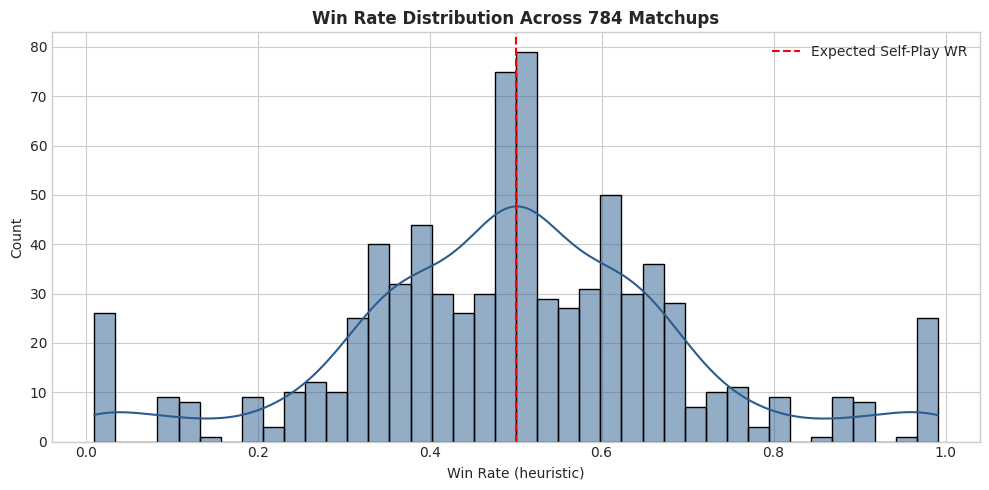

In [15]:
win_rates = {}

for name, path in sorted(existing_files.items()):
    df = pd.read_csv(path, usecols=["won"])
    wr = df["won"].mean()
    win_rates[name] = wr

# Self-play win rate check (should be ~0.5 within statistical tolerance)
self_play_deviations = []
for ag in ALL_AGENTS:
    key = f"{ag}_vs_{ag}.csv"
    if key in win_rates:
        wr = win_rates[key]
        n = row_counts.get(key, 10000)
        # 99% CI for binomial: ~2.58 * sqrt(0.25/n)
        ci = 2.58 * np.sqrt(0.25 / n)
        if abs(wr - 0.5) > ci:
            self_play_deviations.append((ag, wr, n, ci))

# Reciprocal consistency: WR(X,Y) + WR(Y,X) ≈ 1
reciprocal_errors = []
for ag in ALL_AGENTS:
    for opp in ALL_AGENTS:
        if ag >= opp:
            continue
        k1 = f"{ag}_vs_{opp}.csv"
        k2 = f"{opp}_vs_{ag}.csv"
        if k1 in win_rates and k2 in win_rates:
            total = win_rates[k1] + win_rates[k2]
            # Tolerance depends on sample sizes
            n1 = row_counts.get(k1, 10000)
            n2 = row_counts.get(k2, 10000)
            tol = 2.58 * np.sqrt(0.25/n1 + 0.25/n2)
            if abs(total - 1.0) > tol:
                reciprocal_errors.append((k1, win_rates[k1], k2, win_rates[k2], total, tol))

print(f"Win Rate Range     : [{min(win_rates.values()):.4f}, {max(win_rates.values()):.4f}]")
print(f"Mean Win Rate      : {np.mean(list(win_rates.values())):.4f}")
print(f"\nSelf-Play Deviations (beyond 99% CI from 0.5): {len(self_play_deviations)}")
for ag, wr, n, ci in self_play_deviations:
    print(f"  {ag} vs {ag}: WR = {wr:.4f} (n={n:,}, 99% CI = ±{ci:.4f})")

print(f"\nReciprocal Errors (|WR(X,Y)+WR(Y,X) - 1| > 99% CI): {len(reciprocal_errors)}")
for k1, wr1, k2, wr2, total, tol in reciprocal_errors[:10]:
    print(f"  {k1} ({wr1:.4f}) + {k2} ({wr2:.4f}) = {total:.4f}  (tol={tol:.4f})")

if not self_play_deviations and not reciprocal_errors:
    print("\n✅ Win rates are statistically consistent.")

# Win rate distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
wr_values = list(win_rates.values())
sns.histplot(wr_values, bins=40, kde=True, color="#2b5c8f", ax=ax)
ax.axvline(0.5, color="red", ls="--", label="Expected Self-Play WR")
ax.set_title("Win Rate Distribution Across 784 Matchups", fontweight="bold")
ax.set_xlabel("Win Rate (heuristic)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "win_rate_distribution.png", dpi=300)
plt.show()

## 16 · Tournament Coverage Heatmap (28×28)

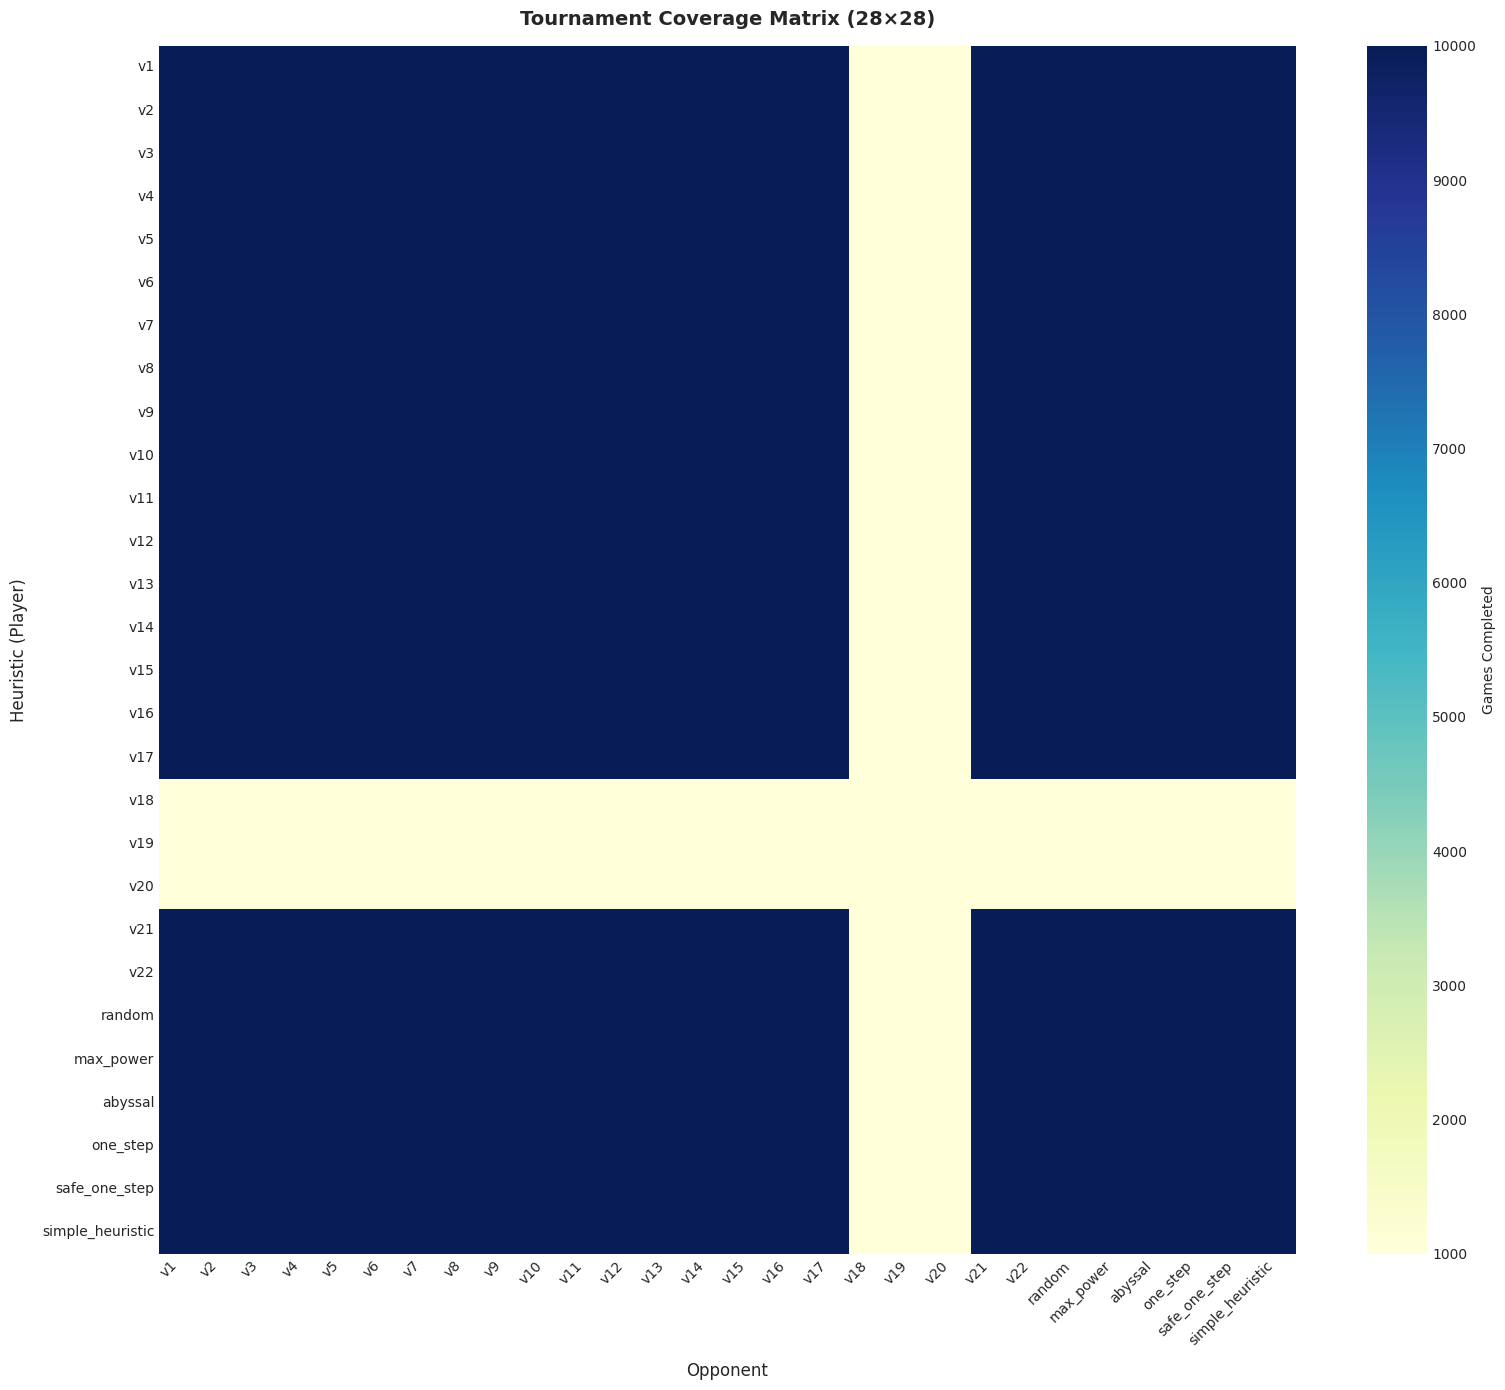

Matrix Cells Filled : 784 / 784
Cells = 10,000      : 625
Cells = 1,000       : 159
Cells = Other       : 0
Total Games         : 6,409,000


In [16]:
matrix_data = np.zeros((len(ALL_AGENTS), len(ALL_AGENTS)), dtype=int)

for i, ag in enumerate(ALL_AGENTS):
    for j, opp in enumerate(ALL_AGENTS):
        key = f"{ag}_vs_{opp}.csv"
        matrix_data[i, j] = row_counts.get(key, 0)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(matrix_data, xticklabels=ALL_AGENTS, yticklabels=ALL_AGENTS,
            cmap="YlGnBu", annot=False, cbar_kws={"label": "Games Completed"}, ax=ax)
ax.set_title("Tournament coverage (28×28)\nv1–v14 heuristic · v15–v17 minimax · v18–v20 MCTS · v21–v22 IL", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Opponent", fontsize=12, labelpad=10)
ax.set_ylabel("Player", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "tournament_coverage_heatmap.png", dpi=300)
plt.show()

# Coverage stats
cells_filled = (matrix_data > 0).sum()
cells_10k = (matrix_data == EXPECTED_ROWS_FULL).sum()
cells_1k = (matrix_data == EXPECTED_ROWS_REDUCED).sum()
cells_other = cells_filled - cells_10k - cells_1k

print(f"Matrix Cells Filled : {cells_filled} / {len(ALL_AGENTS)**2}")
print(f"Cells = 10,000      : {cells_10k}")
print(f"Cells = 1,000       : {cells_1k}")
print(f"Cells = Other       : {cells_other}")
print(f"Total Games         : {matrix_data.sum():,}")

## 17 · Executive Summary Dashboard

In [20]:
checks = [
    ("File Inventory (784 files)",                  len(missing_files) == 0),
    ("No Unexpected Files",                         len(unexpected_files) == 0),
    ("Row Counts (10k/1k)",                         len(row_count_errors) == 0),
    ("Schema Uniformity (50 or 70 cols)",            len(schema_errors) == 0),
    ("CSV Parse Health",                             len(parse_errors) == 0),
    ("Filename ↔ Content Match",                     len(consistency_errors) == 0),
    ("Domain Checks (won/format/winner)",            len(domain_errors) == 0),
    ("Numeric Ranges",                               len(range_violations) == 0),
    ("No Critical Nulls",                            len(critical_nulls) == 0),
    ("Timestamp ISO-8601",                           ts_missing == 0 and ts_malformed == 0),
    ("Zero Content Duplicates",                      total_content_dups == 0),
    ("Battle ID Format (legacy + worker-prefixed)",  len(bad_battle_ids) == 0),
    ("Team String Format",                           len(team_format_errors) == 0),
    ("Fainted+Remaining Invariant (≤6 both sides)",  opp_over6_violations == 0),
    ("Self-Play Win Rates (≈0.5)",                   len(self_play_deviations) == 0),
]

print("═" * 70)
print("    TFM POKÉMON BENCHMARK — DATASET INTEGRITY REPORT")
print("═" * 70)
print(f"  Total Files          : {len(existing_files)} / 784")
print(f"  Total Rows           : {total_rows:,}")
print(f"  Files × 10,000       : {files_10k}")
print(f"  Files × 1,000        : {files_1k} (v18/v19/v20 matchups)")
print(f"  Disk Size            : {total_gb:.2f} GB")
print(f"  Schema: 50-col (base): {schema_counts.get(50, 0)} files")
print(f"  Schema: 70-col (ext) : {schema_counts.get(70, 0)} files")
print(f"  Date Range           : {ts_date_range[0][:10]} → {ts_date_range[1][:10]}")
print("─" * 70)

all_passed = True
for label, passed in checks:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        all_passed = False
    print(f"  {status}  {label}")

# Info-only checks (not pass/fail)
print("─" * 70)
print(f"  ℹ️  INFO  Win/Fainted edge cases: {win_fainted_total:,} ({pct:.4f}% — timer/forfeit)")
print(f"  ℹ️  INFO  Reciprocal WR deviations: {len(reciprocal_errors)} (beyond 99% CI)")
ms_total = null_counts_global.get('move_stats_us', 0) + null_counts_global.get('move_stats_opp', 0)
print(f"  ℹ️  INFO  move_stats nulls: {ms_total:,} ({100*ms_total/(total_rows*2):.5f}%)")

print("═" * 70)
if all_passed:
    print("  🏆 DATASET INTEGRITY VERIFIED — READY FOR ANALYSIS")
else:
    fails = sum(1 for _, p in checks if not p)
    print(f"  ⚠️  {fails} CHECK(S) FAILED — REVIEW ABOVE SECTIONS")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
    TFM POKÉMON BENCHMARK — DATASET INTEGRITY REPORT
══════════════════════════════════════════════════════════════════════
  Total Files          : 784 / 784
  Total Rows           : 6,409,000
  Files × 10,000       : 625
  Files × 1,000        : 159 (v18/v19/v20 matchups)
  Disk Size            : 5.80 GB
  Schema: 50-col (base): 347 files
  Schema: 70-col (ext) : 437 files
  Date Range           : 2026-05-27 → 2026-08-12
──────────────────────────────────────────────────────────────────────
  ✅ PASS  File Inventory (784 files)
  ✅ PASS  No Unexpected Files
  ✅ PASS  Row Counts (10k/1k)
  ✅ PASS  Schema Uniformity (50 or 70 cols)
  ✅ PASS  CSV Parse Health
  ✅ PASS  Filename ↔ Content Match
  ✅ PASS  Domain Checks (won/format/winner)
  ✅ PASS  Numeric Ranges
  ✅ PASS  No Critical Nulls
  ✅ PASS  Timestamp ISO-8601
  ✅ PASS  Zero Content Duplicates
  ✅ PASS  Battle ID Format (legacy + worker-prefixed)
  ✅ PASS  Team